# Assignment 7: Data Visualization I
## Visualization using Matplotlib

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement

To create visualizations using Matplotlib: line plots (multiple lines with labels and legends), bar charts (vertical and horizontal), histograms, pie charts (with percentage labels and explode), scatter plots (with color mapping and size variation). Customize with titles, axis labels, gridlines, and annotations. Save figures in different formats.

## Theory

**Matplotlib** is the foundational Python visualization library. It gives full control over every element of a figure — axes, ticks, labels, colors, annotations.

**Key Concepts:**
- **Figure:** The entire drawing canvas
- **Axes:** A single plot within the figure
- **pyplot:** The procedural interface (`plt.plot()`, `plt.bar()`, etc.)

**Plot Selection Guide:**
| Question | Plot |
|----------|------|
| Trend over time/sequence? | Line plot |
| Compare categories? | Bar chart |
| Distribution of one variable? | Histogram |
| Proportions of a whole? | Pie chart |
| Relationship between two numerics? | Scatter plot |

In [1]:
# Step 1: Import Required Libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('Libraries imported successfully!')
# Set a clean style
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100

Libraries imported successfully!


In [2]:
# Step 2: Load Dataset
df = pd.read_csv('datasets/tips.csv')
print(f'Tips dataset: {df.shape[0]} rows, columns: {df.columns.tolist()}')
df.head()

Tips dataset: 244 rows, columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


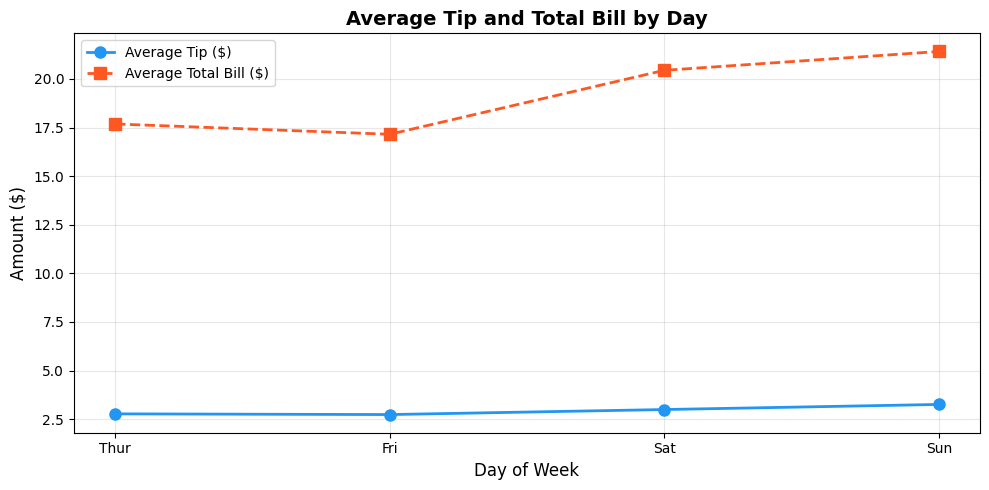

Line plot saved as line_plot.png


In [3]:
# Step 3: Line Plot — Average Tip by Day
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_tips = df.groupby('day')['tip'].mean().reindex(day_order)
avg_total = df.groupby('day')['total_bill'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_tips.index, avg_tips.values, 'o-', color='#2196F3', linewidth=2,
        markersize=8, label='Average Tip ($)')
ax.plot(avg_total.index, avg_total.values, 's--', color='#FF5722', linewidth=2,
        markersize=8, label='Average Total Bill ($)')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Average Tip and Total Bill by Day', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('line_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Line plot saved as line_plot.png')

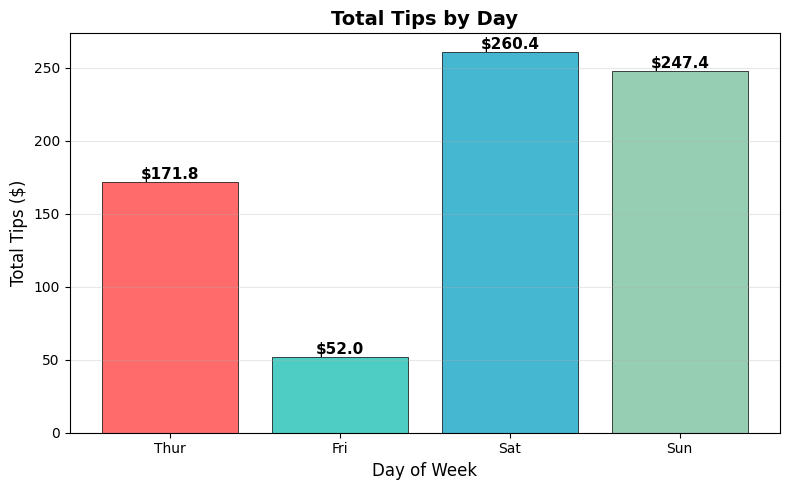

In [4]:
# Step 4: Vertical Bar Chart — Total Tips by Day
daily_tips = df.groupby('day')['tip'].sum().reindex(day_order)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(daily_tips.index, daily_tips.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Total Tips ($)', fontsize=12)
ax.set_title('Total Tips by Day', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, daily_tips.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

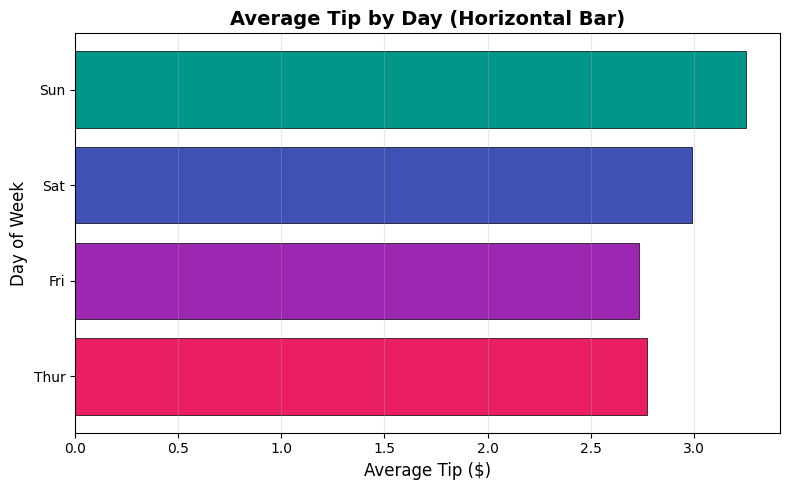

In [5]:
# Step 5: Horizontal Bar Chart — Average Tip by Day
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(avg_tips.index, avg_tips.values, color=['#E91E63', '#9C27B0', '#3F51B5', '#009688'],
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Average Tip ($)', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_title('Average Tip by Day (Horizontal Bar)', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('hbar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

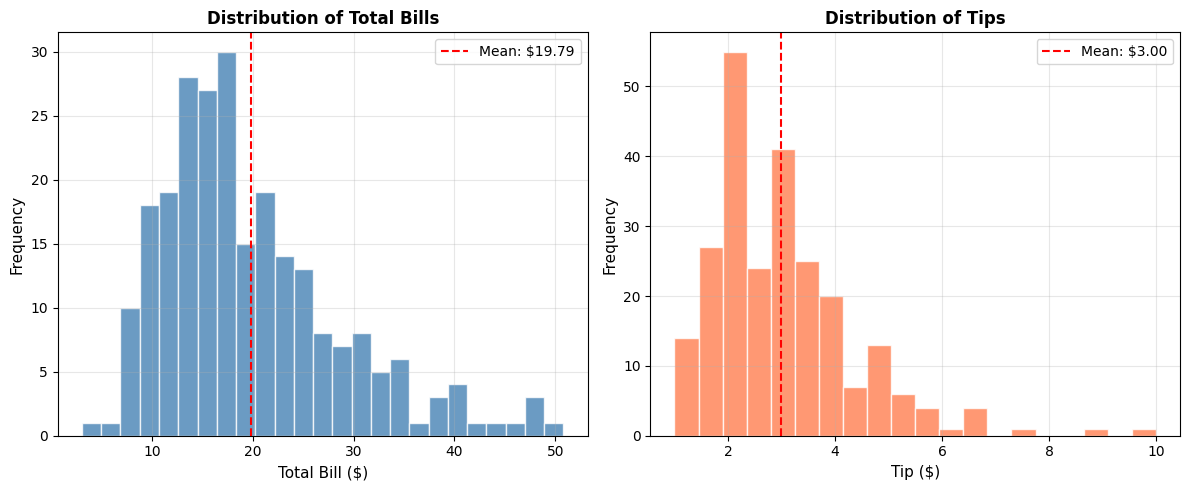

In [6]:
# Step 6: Histogram — Distribution of Total Bill Amounts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with density
axes[0].hist(df['total_bill'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Total Bill ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Total Bills', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(df['total_bill'].mean(), color='red', linestyle='--',
                label=f'Mean: ${df["total_bill"].mean():.2f}')
axes[0].legend()

# Histogram of Tips
axes[1].hist(df['tip'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Tip ($)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Tips', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(df['tip'].mean(), color='red', linestyle='--',
              label=f'Mean: ${df["tip"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()

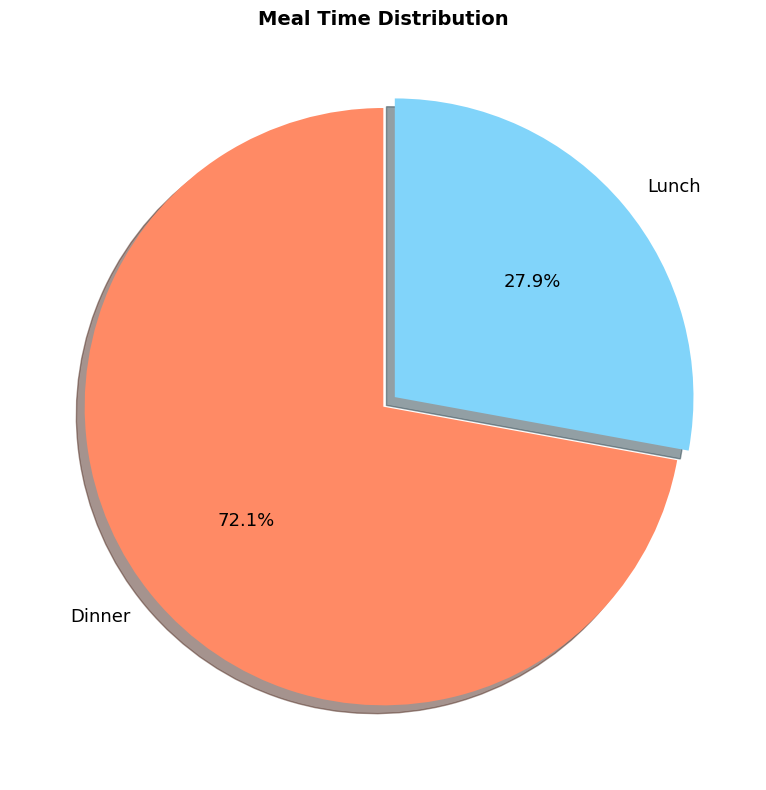

In [7]:
# Step 7: Pie Chart — Meal Time Distribution
meal_counts = df['time'].value_counts()
explode = (0, 0.05)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    meal_counts.values,
    labels=meal_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    colors=['#FF8A65', '#81D4FA'],
    shadow=True,
    startangle=90,
    textprops={'fontsize': 13}
)
ax.set_title('Meal Time Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

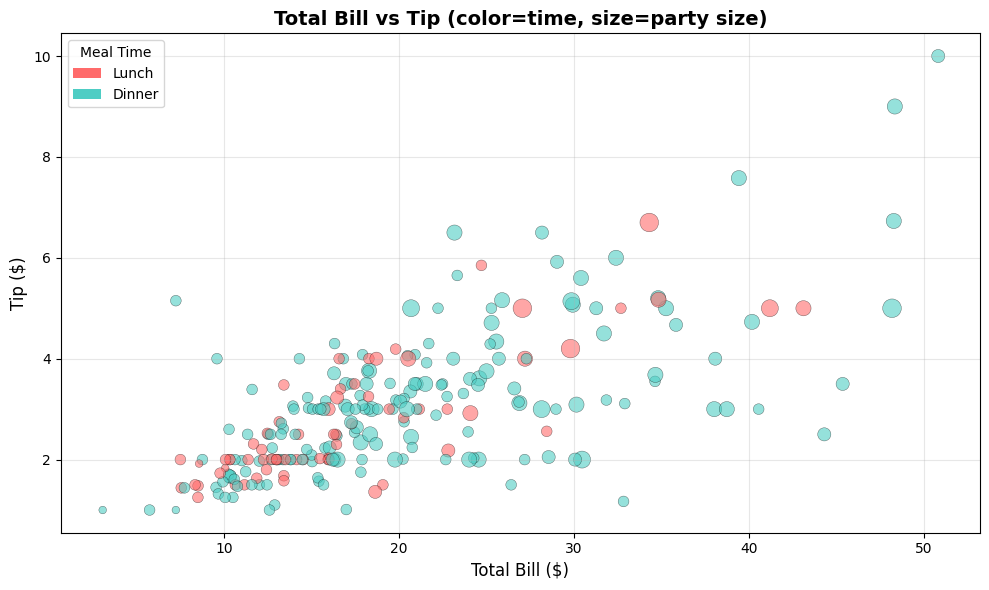

In [8]:
# Step 8: Scatter Plot — Total Bill vs Tip with Color Mapping
fig, ax = plt.subplots(figsize=(10, 6))

# Map time to colors
colors = df['time'].map({'Lunch': '#FF6B6B', 'Dinner': '#4ECDC4'})
sizes = df['size'] * 30  # Scale point size by party size

scatter = ax.scatter(df['total_bill'], df['tip'], c=colors, s=sizes,
                     alpha=0.6, edgecolor='black', linewidth=0.3)

ax.set_xlabel('Total Bill ($)', fontsize=12)
ax.set_ylabel('Tip ($)', fontsize=12)
ax.set_title('Total Bill vs Tip (color=time, size=party size)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label='Lunch'),
                   Patch(facecolor='#4ECDC4', label='Dinner')]
ax.legend(handles=legend_elements, title='Meal Time', loc='upper left')

plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

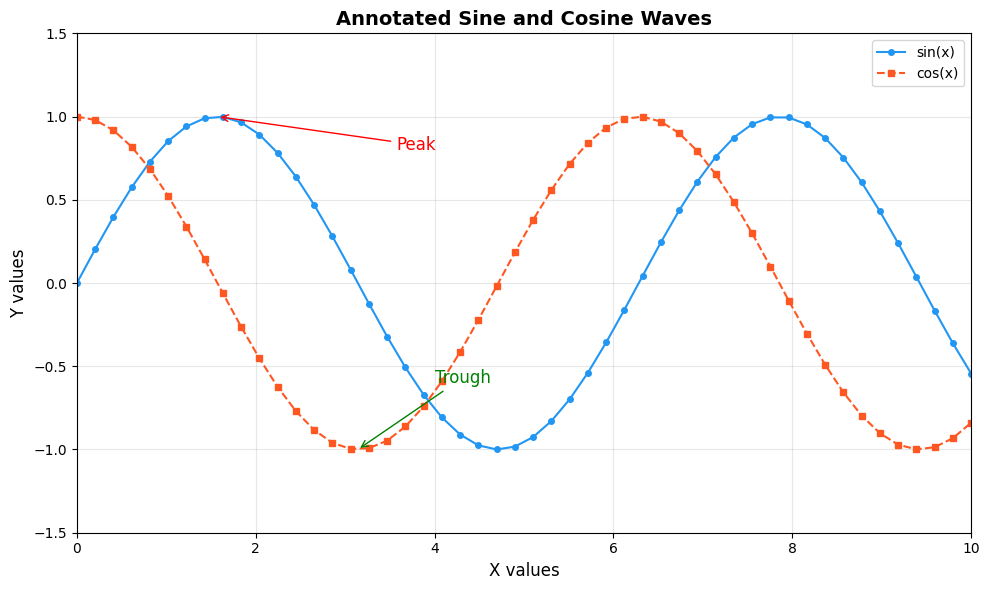

In [9]:
# Step 9: Annotation and Customization Demo
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with full customization
x = np.linspace(0, 10, 50)
ax.plot(x, np.sin(x), 'o-', label='sin(x)', color='#2196F3', markersize=4)
ax.plot(x, np.cos(x), 's--', label='cos(x)', color='#FF5722', markersize=4)

# Annotations
ax.annotate('Peak', xy=(np.pi/2, 1), xytext=(np.pi/2 + 2, 0.8),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')
ax.annotate('Trough', xy=(np.pi, -1), xytext=(4, -0.6),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=12, color='green')

ax.set_xlabel('X values', fontsize=12)
ax.set_ylabel('Y values', fontsize=12)
ax.set_title('Annotated Sine and Cosine Waves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('annotated_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Step 10: Summary
print('=' * 60)
print('ASSIGNMENT 7 — MATPLOTLIB VISUALIZATIONS COMPLETED')
print('=' * 60)
print()
print('Plots created:')
print('  1. Multi-line plot with legend (Tips by day)')
print('  2. Vertical bar chart with value labels')
print('  3. Horizontal bar chart')
print('  4. Histograms (total_bill & tip distribution)')
print('  5. Pie chart with explode and percentage labels')
print('  6. Scatter plot with color mapping and size variation')
print('  7. Annotated plot with arrows and text')
print()
print('All plots include: titles, axis labels, legends, gridlines')
print('Figures saved as: line_plot.png, bar_chart.png, hbar_chart.png,')
print('  histograms.png, pie_chart.png, scatter_plot.png, annotated_plot.png')

ASSIGNMENT 7 — MATPLOTLIB VISUALIZATIONS COMPLETED

Plots created:
  1. Multi-line plot with legend (Tips by day)
  2. Vertical bar chart with value labels
  3. Horizontal bar chart
  4. Histograms (total_bill & tip distribution)
  5. Pie chart with explode and percentage labels
  6. Scatter plot with color mapping and size variation
  7. Annotated plot with arrows and text

All plots include: titles, axis labels, legends, gridlines
Figures saved as: line_plot.png, bar_chart.png, hbar_chart.png,
  histograms.png, pie_chart.png, scatter_plot.png, annotated_plot.png


## Dataset Description

- **Dataset:** Tips (seaborn built-in, from datasets/tips.csv)
- **Records:** 244 restaurant transactions
- **Features:** total_bill, tip, sex, smoker, day, time, size

## Conclusion

All seven required plot types were successfully created and saved as image files. Each plot includes proper titles, axis labels, legends, and gridlines. The line plot shows average tips by day with two data series; bar charts compare categories both vertically and horizontally; histograms reveal the right-skewed nature of bills and tips; the pie chart displays meal time proportions with explode effect; the scatter plot uses color and size to encode two additional variables. Annotations demonstrate how to highlight specific data points of interest.